# Physics-Informed HVAC Energy Prediction under Incomplete Sensor Data

Sathish Kumar Konda (25190890), MSc in Artificial Intelligence, National College of Ireland.

This notebook reproduces the full study on the LBNL Building 59 dataset (Luo et al., 2022):

1. environment set-up (Google Colab, Jupyter, macOS or Windows; CUDA, Apple MPS or CPU),
2. data loading and profiling,
3. unit tests,
4. the experiment (baseline re-implementation, proposed physics-informed GRU, ablations, five seeds, controlled sensor loss),
5. statistics, tables and figures used in the report.

The principal baseline is Mahajan et al. (2024), *Sustainability* 16(22), 9943, which predicts hourly HVAC energy of the same building on the same test window (July-December 2020) from complete, forward-filled data.

`RUN_FULL = False` reuses the stored results in `results/` and only runs a short smoke experiment. Set it to `True` to re-run every experiment (about 40-60 minutes on a laptop GPU or 8 CPU cores).

In [1]:
RUN_FULL = False

## 1. Environment

In [2]:
import importlib.util
import os
import pathlib
import subprocess
import sys

REPO = "https://github.com/Tarunchintakunta/Thesis-2.0.git"


def find_root():
    here = pathlib.Path.cwd().resolve()
    for cand in (here, here.parent, here / "satish-thesis", here / "Thesis-2.0" / "satish-thesis"):
        if (cand / "src" / "experiment.py").exists():
            return cand
    subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", REPO, "Thesis-2.0"], check=True)
    subprocess.run(["git", "-C", "Thesis-2.0", "sparse-checkout", "set", "satish-thesis"], check=True)
    return (here / "Thesis-2.0" / "satish-thesis").resolve()


ROOT = find_root()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

needed = {"xgboost": "xgboost", "torch": "torch", "sklearn": "scikit-learn", "scipy": "scipy",
          "matplotlib": "matplotlib", "pandas": "pandas", "pytest": "pytest"}
missing = [pkg for mod, pkg in needed.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
print("project root:", ROOT)
print("python:", sys.version.split()[0])

project root: /Users/tarunchintakunta/Desktop/Thesis2.0/satish-thesis
python: 3.13.9


In [3]:
def run(*args):
    """Run a project script in a fresh interpreter and stream its output."""
    env = {**os.environ, "PYTHONUNBUFFERED": "1", "PYTHONWARNINGS": "ignore",
           "PYTHONPATH": os.pathsep.join([str(ROOT / "src"), os.environ.get("PYTHONPATH", "")])}
    proc = subprocess.Popen([sys.executable, *args], cwd=ROOT, env=env, stdout=subprocess.PIPE,
                            stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace")
    for line in proc.stdout:
        print(line, end="")
    if proc.wait() != 0:
        raise RuntimeError(f"{' '.join(args)} failed with exit code {proc.returncode}")


run("-c", "import torch; from models import pick_device; print('torch', torch.__version__, '| device:', pick_device())")

torch 2.11.0 | device: mps


## 2. Data

`data/bldg59_hourly.csv.gz` is the hourly table built by `src/prepare_data.py` from the raw Building 59 files. To rebuild it from the raw data, run `scripts/download_data.sh` (needs a Kaggle token) and then `python src/prepare_data.py`.

In [4]:
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from experiment import PERIODS, load_hourly

df = load_hourly()
print(df.shape, df.index.min(), "to", df.index.max())
print("splits:", PERIODS)
display(pd.read_csv("results/data_dictionary.csv"))
display(df.describe().T.round(2))

(24888, 14) 2018-03-01 00:00:00 to 2020-12-31 23:00:00
splits: {'train': ('2018-03-01', '2020-03-31 23:00'), 'val': ('2020-04-01', '2020-06-30 23:00'), 'test': ('2020-07-01', '2020-12-31 22:00')}


,column,unit,source,description
0,hvac_kwh,kWh,ele.csv hvac_N + hvac_S,"HVAC electricity in the hour (forecast target,..."
1,t_in,degC,zone_temp_interior.csv,Median of 16 indoor air-temperature loggers
2,t_out,degC,site_weather.csv air_temp_set_1,"Outdoor air temperature, LBNL weather station"
3,rh_out,%,site_weather.csv relative_humidity_set_1,Outdoor relative humidity
4,solar,W/m2,site_weather.csv solar_radiation_set_1,Global solar radiation
5,q_int,kW,ele.csv mels_N + mels_S + lig_S,"Plug-load and lighting power, internal heat-ga..."
6,t_sa,degC,rtu_sa_t.csv mean of 4 RTUs,Supply-air temperature
7,t_ra,degC,rtu_ra_t.csv mean of 4 RTUs,Return-air temperature
8,fan,%,rtu_fan_spd.csv supply-fan VFD mean,Supply-fan speed feedback
9,natural_gap,0/1,derived,1 if any column was missing in the raw data fo...


,count,mean,std,min,25%,50%,75%,max
hvac_kwh,23680.0,39.35,19.70,0.00,28.64,36.94,52.05,123.13
t_in,24783.0,23.45,0.79,19.61,23.05,23.47,23.95,26.55
t_out,24888.0,14.39,5.22,1.43,10.76,13.30,17.24,41.97
rh_out,24888.0,66.30,21.51,5.65,51.78,70.28,85.00,95.50
solar,24888.0,193.81,276.52,0.00,0.03,9.68,354.07,1016.75
q_int,24051.0,12.62,10.17,0.39,3.69,10.75,16.53,50.83
t_sa,22547.0,19.39,1.00,10.88,18.87,19.45,20.01,32.91
t_ra,24888.0,21.69,1.17,8.75,21.39,21.84,22.13,40.32
fan,24703.0,76.59,11.07,0.39,72.77,77.46,83.10,100.00
natural_gap,24888.0,0.14,0.35,0.00,0.00,0.00,0.00,1.00


In [5]:
profile = json.loads(pathlib.Path("results/data_profile.json").read_text(encoding="utf-8"))
pd.DataFrame({"natural gaps (%)": profile["raw_missing_pct"],
              "correlation with HVAC": profile["corr_with_hvac"]}).round(3)

,natural gaps (%),correlation with HVAC
hvac_kwh,5.023,1.000
t_in,0.458,0.218
t_out,0.000,0.449
rh_out,0.000,-0.230
solar,0.000,0.244
q_int,3.508,0.253
t_sa,9.780,0.110
t_ra,0.000,0.299
fan,0.820,0.510


## 3. Unit tests

In [6]:
run("-m", "pytest", "tests", "-q", "--color=no", "-p", "no:cacheprovider")

...................                                                      [100%]
19 passed in 1.28s


## 4. Experiment

`src/experiment.py` runs two tasks. **estimate** is the primary task and follows the baseline: hourly HVAC energy is predicted from building and weather sensors without the HVAC meter history. **forecast** is supplementary: the next hour is predicted with the meter history as an extra input. The tree family (XGBoost and naive baselines) and the neural family run in separate processes.

In [7]:
run("src/experiment.py", "--quick")

have_results = all((ROOT / "results" / f"metrics_{t}_{f}.csv").exists()
                   for t in ("estimate", "forecast") for f in ("tree", "nn"))
if RUN_FULL or not have_results:
    run("src/experiment.py")
else:
    print("Stored full results found in results/. Set RUN_FULL = True to recompute them.")

{'task': 'estimate', 'family': 'tree', 'device': 'cpu', 'train': 16912, 'val': 2183, 'test': 4414, 'fit': 19095, 'periods': {'train': ('2018-03-01', '2020-03-31 23:00'), 'val': ('2020-04-01', '2020-06-30 23:00'), 'test': ('2020-07-01', '2020-12-31 22:00')}, 'started': '2026-09-30 23:30', 'torch': '2.11.0'}


{'model': 'XGBoost', 'max_depth': 6, 'learning_rate': 0.05, 'val_rmse': 6.5312059750544895, 'train_s': 0.4087862968444824}
chosen {'XGBoost': {'max_depth': 6, 'learning_rate': 0.05}}


[tree] seed 0 evaluated


[tree] imputer mean seed 0 done


[tree] imputer cart seed 0 done


...

seed 0 GRU-aux: val 3.821 in 5s (2 ep)


seed 0 PI-GRU: val 4.066 in 5s (2 ep)


seed 0 PI-GRU-nomask: val 3.674 in 5s (2 ep)


[nn] seed 0 evaluated


Stored full results found in results/. Set RUN_FULL = True to recompute them.


## 5. Analysis

In [8]:
run("src/analysis.py")
TAB = ROOT / "results" / "tables"


def show(name):
    display(pd.read_csv(TAB / name))


def fig(name):
    display(Image(filename=str(ROOT / "figures" / name)))

{
 "estimate": {
  "BNN": 10.418,
  "BNN-paper": 12.11,
  "GRU": 9.066,
  "GRU-aux": 8.912,
  "LSTM": 9.438,
  "PI-GRU": 9.012,
  "PI-GRU-nomask": 9.243,
  "Profile": 14.283,
  "XGBoost": 7.966
 },
 "forecast": {
  "BNN": 4.646,
  "BNN-paper": 12.103,
  "GRU": 3.852,
  "GRU-aux": 3.919,
  "LSTM": 4.065,
  "PI-GRU": 3.949,
  "PI-GRU-nomask": 3.987,
  "Persistence": 3.748,
  "Seasonal": 9.97,
  "XGBoost": 3.743
 }
}


### 5.1 Comparison with the baseline paper (complete data)

,model,MAE,RMSE,MAPE,R2
0,QRF (published),17.17,21.67,0.40,--
1,MC-LSTM (published),8.21,11.86,0.45,--
2,BNN (published),7.06,9.65,0.35,--
3,XGBoost,6.03 ± 0.29,7.97 ± 0.45,0.291 ± 0.024,0.634 ± 0.042
4,GRU-aux,5.73 ± 0.64,8.91 ± 0.57,0.215 ± 0.033,0.542 ± 0.059
5,PI-GRU,5.70 ± 0.43,9.01 ± 0.72,0.216 ± 0.022,0.530 ± 0.076
6,GRU,5.65 ± 0.68,9.07 ± 0.67,0.205 ± 0.027,0.525 ± 0.069
7,PI-GRU-nomask,6.01 ± 0.51,9.24 ± 0.65,0.229 ± 0.033,0.507 ± 0.070
8,LSTM,6.04 ± 0.95,9.44 ± 1.09,0.237 ± 0.041,0.482 ± 0.120
9,BNN,6.27 ± 0.50,10.42 ± 0.83,0.231 ± 0.017,0.373 ± 0.098


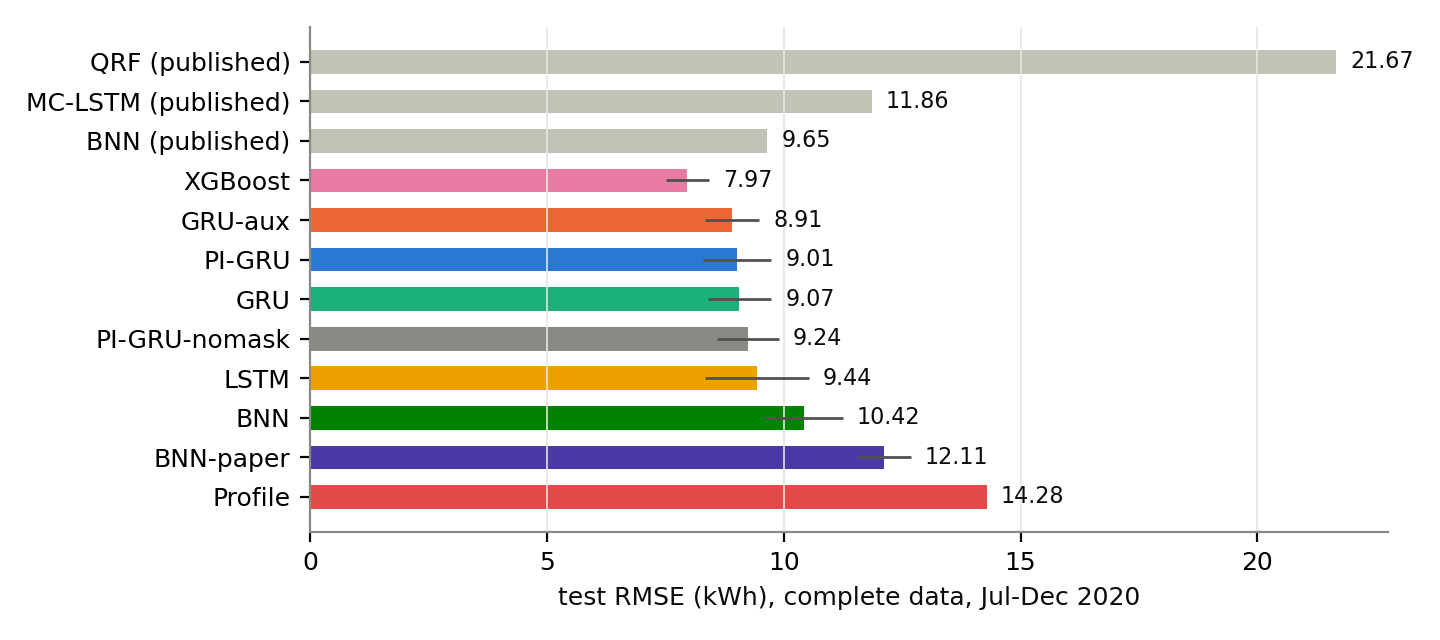

In [9]:
show("baseline_comparison.csv")
fig("baseline_comparison.png")

### 5.2 Robustness to sensor loss (estimation task)

,model,complete,mcar 10%,mcar 20%,mcar 30%,mcar 40%,block 10%,block 20%,block 30%,block 40%,mcar slope,block slope
0,BNN,10.42 ± 0.83,10.16,10.05,9.86,9.72,10.56,10.81,11.60,11.39,-0.170 ± 0.087,0.298 ± 0.205
1,BNN-paper,12.11 ± 0.57,12.14,12.16,12.24,12.30,12.52,12.77,12.82,12.97,0.048 ± 0.013,0.201 ± 0.123
2,Profile,14.28 ± 0.00,14.28,14.28,14.28,14.28,14.28,14.28,14.28,14.28,-0.000 ± 0.000,-0.000 ± 0.000
3,XGBoost,7.97 ± 0.45,8.02,8.09,8.17,8.25,8.27,8.70,8.89,9.52,0.070 ± 0.026,0.373 ± 0.051
4,GRU-aux,8.91 ± 0.57,8.89,8.89,8.92,8.89,9.10,9.59,10.34,10.38,-0.003 ± 0.061,0.417 ± 0.152
5,PI-GRU,9.01 ± 0.72,8.97,8.98,8.98,8.96,9.04,9.78,10.51,10.36,-0.010 ± 0.041,0.418 ± 0.116
6,GRU,9.07 ± 0.67,9.03,9.04,9.06,9.01,9.19,9.77,10.47,10.29,-0.007 ± 0.063,0.373 ± 0.193
7,PI-GRU-nomask,9.24 ± 0.65,9.27,9.27,9.31,9.40,9.68,10.30,10.79,11.41,0.035 ± 0.024,0.543 ± 0.112
8,LSTM,9.44 ± 1.09,9.39,9.38,9.36,9.30,9.58,10.12,10.71,10.61,-0.031 ± 0.051,0.347 ± 0.234


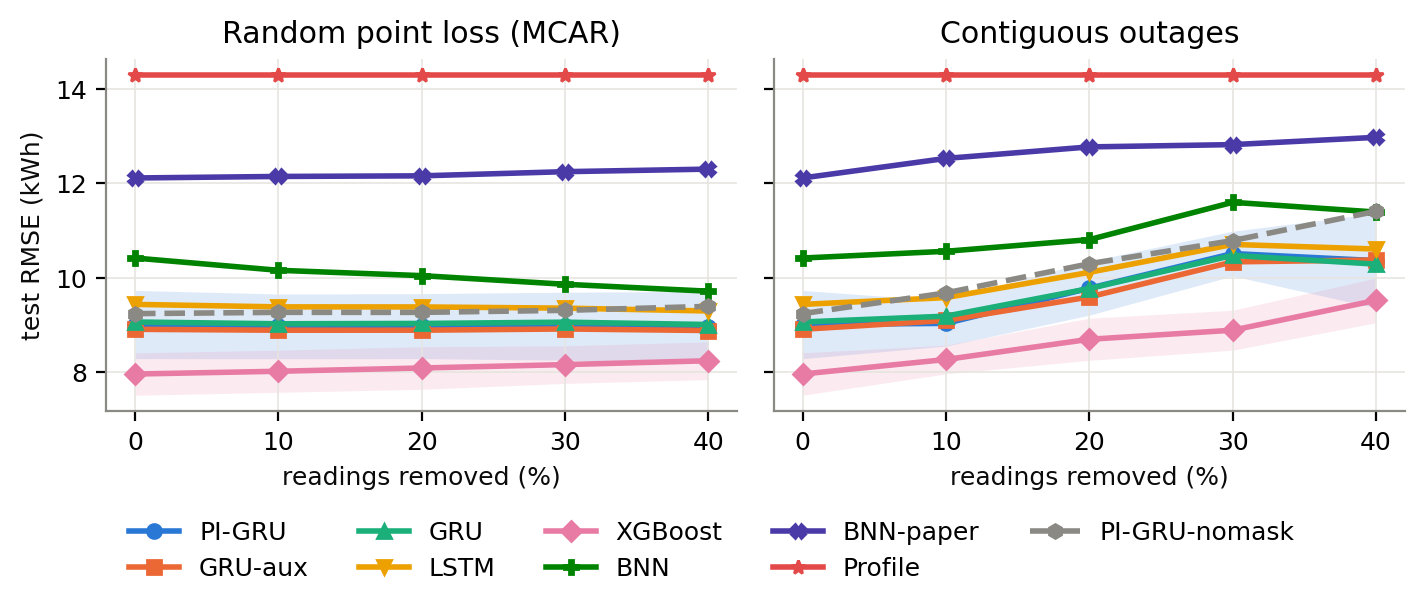

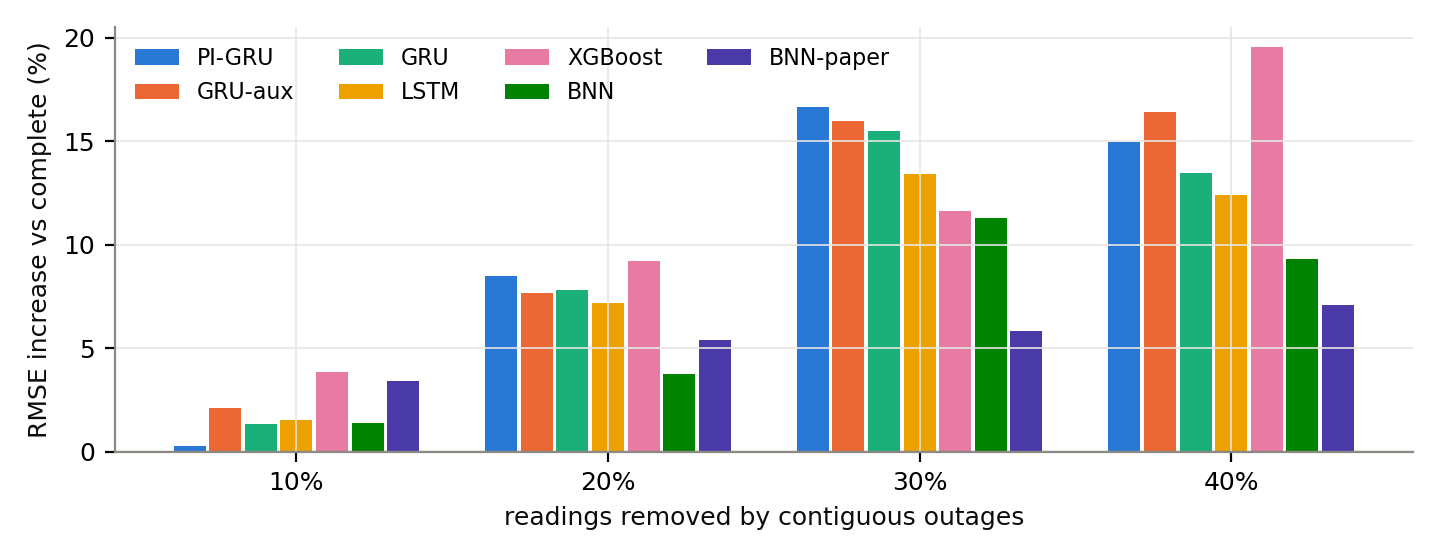

In [10]:
show("robustness_estimate.csv")
fig("robustness_estimate.png")
fig("degradation_estimate.png")

### 5.3 Statistical tests: PI-GRU against the best conventional model and the matched ablation

In [11]:
show("significance_estimate.csv")

,pattern,rate,reference,dRMSE,dRMSE_pct,ci_lo,ci_hi,wilcoxon_p,p_holm
0,none,0.0,XGBoost,1.059439,13.282803,-0.230577,2.325676,0.025226,0.428847
1,none,0.0,GRU-aux,0.109447,1.226154,-0.043562,0.261267,0.986766,1.000000
2,mcar,0.1,XGBoost,0.959827,11.946348,-0.261461,2.385075,0.030626,0.490021
3,mcar,0.1,GRU-aux,0.088914,0.998429,-0.066609,0.225285,0.729665,1.000000
4,mcar,0.2,XGBoost,0.895507,11.050551,-0.299694,2.252796,0.038132,0.571987
5,mcar,0.2,GRU-aux,0.093048,1.044756,-0.063392,0.241787,0.486008,1.000000
6,mcar,0.3,XGBoost,0.826964,10.117893,-0.386841,2.175030,0.064786,0.907002
7,mcar,0.3,GRU-aux,0.067605,0.756833,-0.083996,0.206972,0.425918,1.000000
8,mcar,0.4,XGBoost,0.730639,8.851522,-0.483274,2.099528,0.098851,1.000000
9,mcar,0.4,GRU-aux,0.083975,0.943426,-0.070970,0.231386,0.479113,1.000000


### 5.4 Physical consistency and learned thermal parameters

,model,$\partial E/\partial T_{out}$ (kWh/K),implausible (%),RC residual block 40%,RC residual mcar 40%,RC residual none 0%
0,BNN,0.61 ± 0.28,18.8 ± 18.5,--,--,--
1,BNN-paper,1.26 ± 0.19,7.5 ± 6.6,--,--,--
2,GRU,0.59 ± 0.12,33.3 ± 5.8,--,--,--
3,GRU-aux,0.70 ± 0.06,28.2 ± 10.0,0.268,0.130,0.124
4,LSTM,0.62 ± 0.08,15.3 ± 4.8,--,--,--
5,PI-GRU,0.73 ± 0.13,29.4 ± 4.5,0.266,0.126,0.112
6,PI-GRU-nomask,0.54 ± 0.18,35.0 ± 10.6,0.315,0.142,0.138
7,XGBoost,0.33 ± 0.02,7.4 ± 1.7,--,--,--


,model,$\tau$ (h),$b$,$c$,$d$,$e$
0,PI-GRU,48.9 ± 6.2,0.0025 ± 0.0005,0.0055 ± 0.0008,0.0045 ± 0.0005,0.1957 ± 0.0029
1,PI-GRU-nomask,39.1 ± 9.4,0.0016 ± 0.0007,0.0074 ± 0.0016,0.0060 ± 0.0012,0.1962 ± 0.0037
2,Least-squares RC (train),n.i. ($a$=-1.6e-05),0.0005,0.0027,0.1399,-0.0527


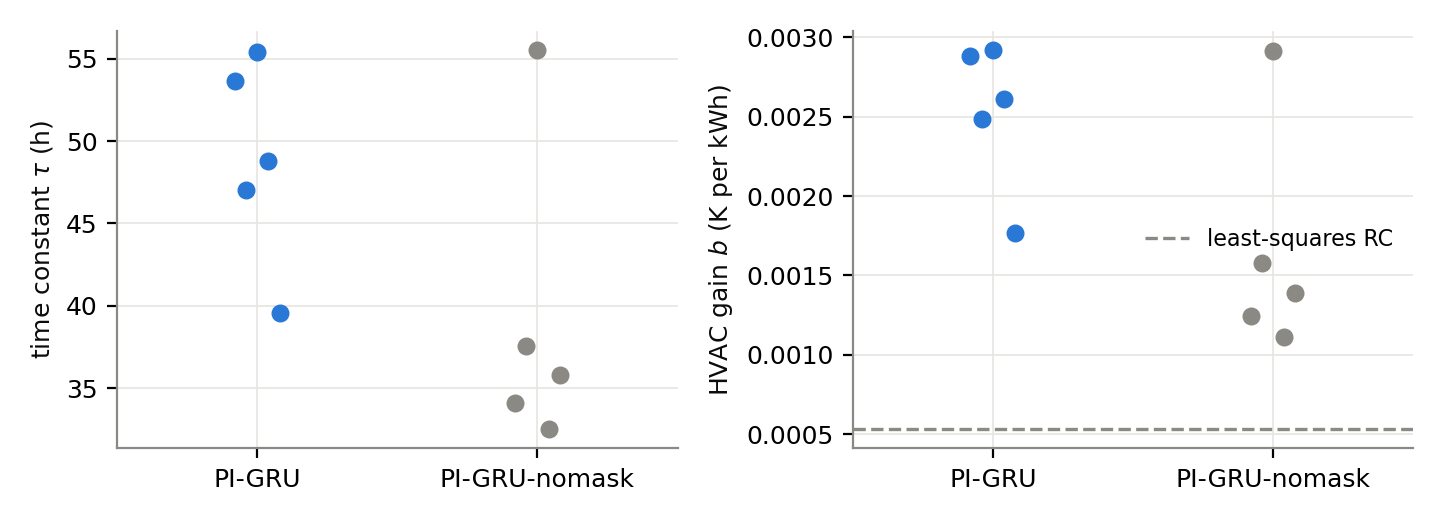

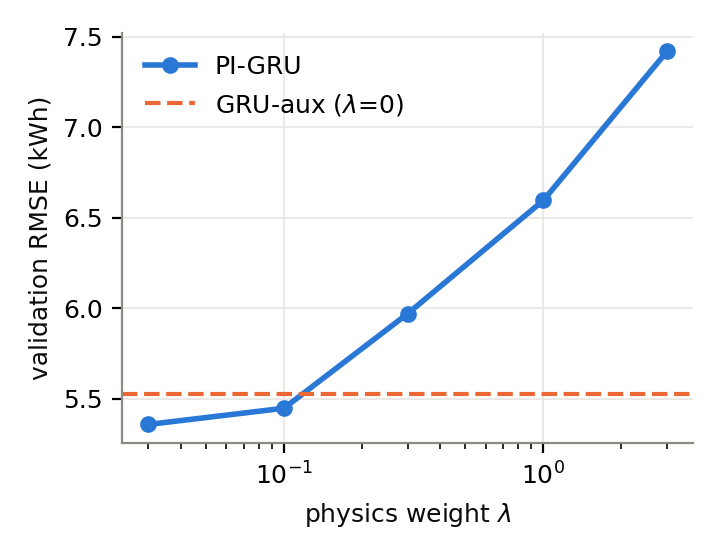

In [12]:
show("physics_consistency_estimate.csv")
show("physics_coefs_estimate.csv")
fig("physics_coefs_estimate.png")
fig("lambda_sensitivity_estimate.png")

### 5.5 Operating strata, imputation choice and cost

In [13]:
show("strata_estimate.csv")
show("imputation_sensitivity.csv")
show("cost_estimate.csv")

,model,condition,occupied,unoccupied,mild T_out,extreme T_out
0,PI-GRU,none 0%,9.16,8.93,7.11,14.26
1,PI-GRU,block 40%,10.83,10.09,9.16,14.16
2,GRU-aux,none 0%,9.00,8.86,7.12,13.93
3,GRU-aux,block 40%,10.87,10.08,9.18,14.15
4,XGBoost,none 0%,8.25,7.80,7.29,10.22
5,XGBoost,block 40%,10.10,9.18,9.11,11.02
6,BNN-paper,none 0%,11.86,12.25,10.95,15.89
7,BNN-paper,block 40%,13.09,12.89,12.00,16.19


,model,imputer,block 20%,block 40%,mcar 20%,mcar 40%,none 0%
0,GRU-aux,cart,9.28,10.44,8.92,8.35,9.25
1,GRU-aux,locf,9.59,10.16,8.63,8.62,8.61
2,GRU-aux,mean,9.73,11.93,9.29,9.21,9.26
3,PI-GRU,cart,9.72,10.68,9.37,8.55,9.86
4,PI-GRU,locf,9.83,10.11,8.81,8.75,8.82
5,PI-GRU,mean,9.46,11.29,8.83,8.72,8.81
6,XGBoost,cart,8.31,9.04,7.93,8.45,7.56
7,XGBoost,locf,8.78,9.49,8.08,8.19,7.96
8,XGBoost,mean,9.21,10.83,8.66,9.70,8.05


,model,train (s),epochs / trees,inference ($\mu$s/sample)
0,BNN,33.3 ± 19.9,11,44.3
1,BNN-paper,13.3 ± 2.3,3,43.0
2,GRU,38.6 ± 20.2,10,9.1
3,GRU-aux,45.4 ± 15.5,12,5.1
4,LSTM,6.6 ± 1.8,4,12.0
5,PI-GRU,50.7 ± 10.7,13,4.6
6,PI-GRU-nomask,34.4 ± 18.2,8,4.5
7,XGBoost,0.9 ± 0.1,20,0.2


### 5.6 Example week

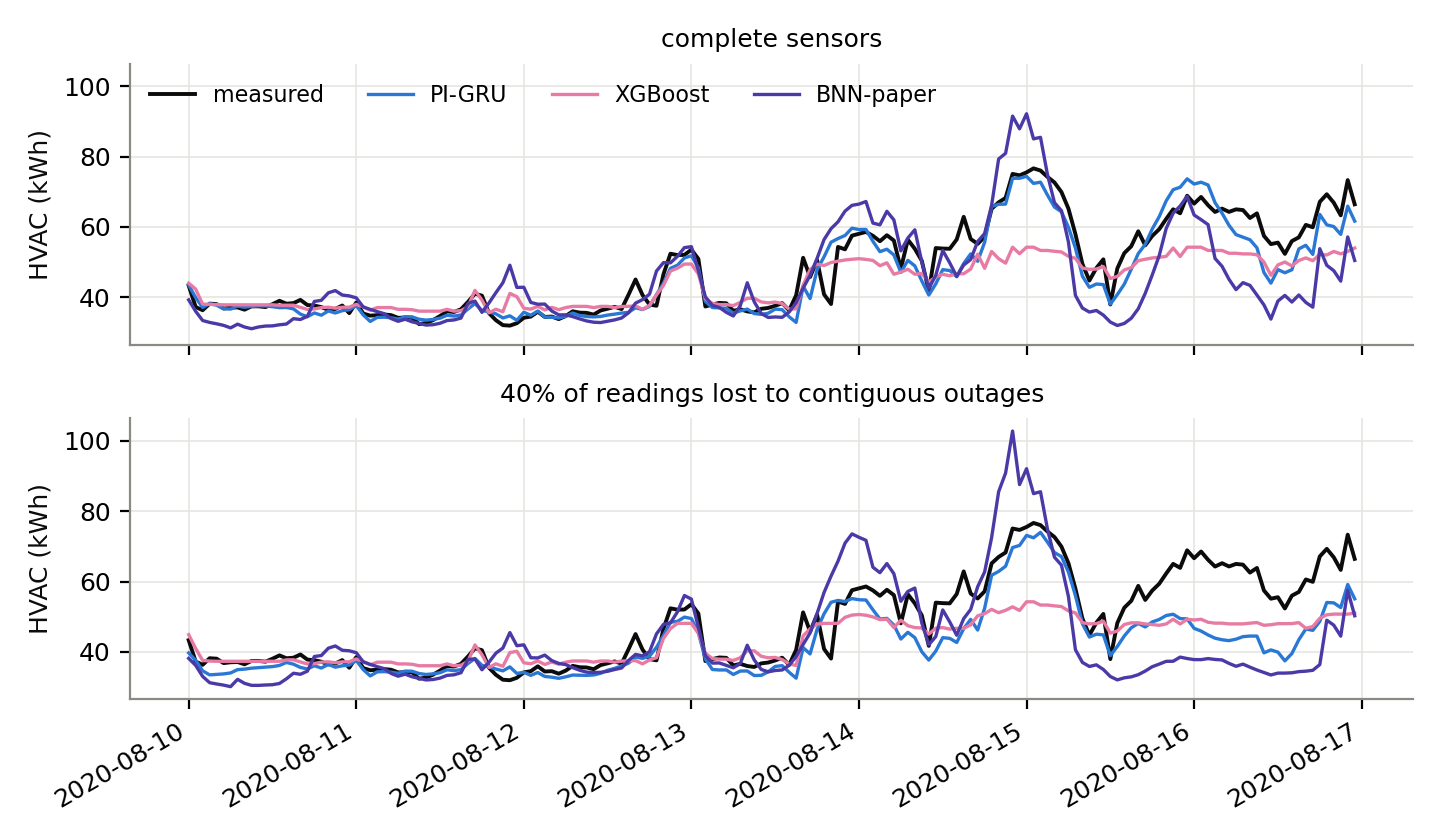

In [14]:
fig("trace_estimate.png")

### 5.7 Supplementary: one-hour-ahead forecasting with meter history

,model,complete,mcar 10%,mcar 20%,mcar 30%,mcar 40%,block 10%,block 20%,block 30%,block 40%,mcar slope,block slope
0,BNN-paper,12.10 ± 0.55,12.15,12.15,12.25,12.28,12.52,12.78,12.79,12.96,0.047 ± 0.011,0.199 ± 0.125
1,XGBoost,3.74 ± 0.02,3.74,3.75,3.75,3.76,3.75,3.77,3.77,3.78,0.004 ± 0.001,0.010 ± 0.005
2,Persistence,3.75 ± 0.00,3.75,3.75,3.75,3.75,3.75,3.75,3.75,3.75,-0.000 ± 0.000,-0.000 ± 0.000
3,GRU,3.85 ± 0.06,3.87,3.90,3.91,3.93,3.84,3.92,3.92,3.91,0.019 ± 0.009,0.020 ± 0.010
4,GRU-aux,3.92 ± 0.05,3.94,3.97,3.99,4.02,3.94,3.99,4.02,4.09,0.025 ± 0.009,0.042 ± 0.007
5,PI-GRU,3.95 ± 0.10,3.97,4.02,4.04,4.08,3.99,4.08,4.09,4.14,0.032 ± 0.014,0.048 ± 0.019
6,PI-GRU-nomask,3.99 ± 0.05,4.00,4.02,4.02,4.02,4.00,4.04,4.02,4.07,0.008 ± 0.004,0.019 ± 0.011
7,LSTM,4.07 ± 0.20,4.08,4.10,4.12,4.13,4.04,4.10,4.13,4.09,0.018 ± 0.012,0.015 ± 0.021
8,BNN,4.65 ± 0.36,4.71,4.75,4.77,4.83,4.74,4.83,4.80,4.83,0.042 ± 0.025,0.042 ± 0.069
9,Seasonal,9.97 ± 0.00,9.97,9.97,9.97,9.97,9.97,9.97,9.97,9.97,-0.000 ± 0.000,-0.000 ± 0.000


,pattern,rate,reference,dRMSE,dRMSE_pct,ci_lo,ci_hi,wilcoxon_p,p_holm
0,none,0.0,XGBoost,0.207256,5.537473,0.090451,0.330469,1.200782e-03,1.561017e-02
1,none,0.0,GRU-aux,0.030600,0.780727,-0.004125,0.070246,1.424836e-01,7.124182e-01
2,mcar,0.1,XGBoost,0.231473,6.182164,0.111514,0.368587,1.189491e-04,2.022134e-03
3,mcar,0.1,GRU-aux,0.039693,1.008467,0.003478,0.080066,5.844457e-02,3.506674e-01
4,mcar,0.2,Persistence,0.268996,7.177636,0.123176,0.432659,1.236169e-03,1.561017e-02
5,mcar,0.2,GRU-aux,0.042820,1.077550,0.006204,0.086793,9.171146e-03,7.336916e-02
6,mcar,0.3,Persistence,0.289478,7.724173,0.141853,0.453012,5.659694e-04,7.923572e-03
7,mcar,0.3,GRU-aux,0.048302,1.210927,0.008843,0.090091,9.663650e-03,7.336916e-02
8,mcar,0.4,Persistence,0.331301,8.840132,0.186255,0.498846,1.310495e-05,2.489941e-04
9,mcar,0.4,GRU-aux,0.059680,1.484841,0.020192,0.103218,4.106845e-04,6.570951e-03


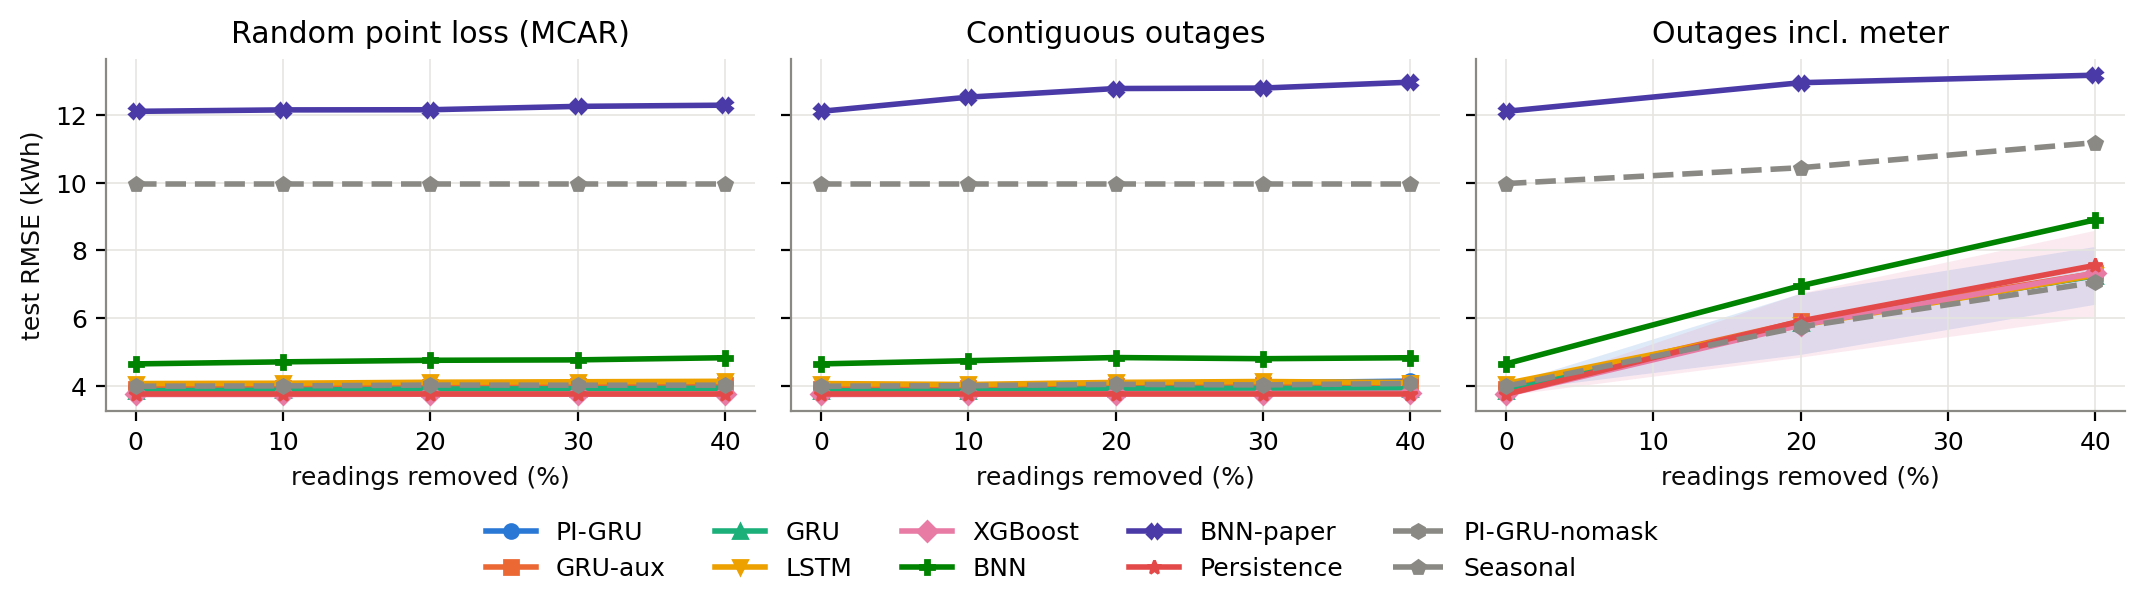

In [15]:
show("robustness_forecast.csv")
show("significance_forecast.csv")
fig("robustness_forecast.png")